In [1]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader

# MLFlow Visualization
import mlflow
import mlflow.pytorch
import os
from torchvision.utils import save_image
import torchvision.utils as utils

mlflow.set_experiment('mnist_gan')

<Experiment: artifact_location='/home/jan/Uni/Applied_Deep-Learning/GAN/mlruns/1', creation_time=1780218937093, experiment_id='1', last_update_time=1780218937093, lifecycle_stage='active', name='mnist_gan', tags={}, trace_location=None, workspace='default'>

In [2]:
# Hyperparameters
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
learning_rate = 3e-4
batch_size = 32  # Batch size
num_epochs = 100

latent_dimension = 128 # 64, 128, 256
# for simplicity we will flatten the image to a vector and to use simple MLP networks
# 28 * 28 * 1 flattens to 784
# you are also free to use CNNs
image_dimension = 28 * 28 * 1  # 784

# we define a tranform that converts the image to tensor and normalizes it with mean and std of 0.5
# which will convert the image range from [0, 1] to [-1, 1]
myTransforms = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

In [3]:
# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loading MNIST digits dataset


In [4]:
class Generator(nn.Module):
    """
    Generator Model
    """

    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential( # pyright: ignore
            nn.Linear(latent_dimension, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 784),            
            nn.Tanh(),  # It is helpful to use the tanh activation function to force the output into the [-1,1] range that our normalized images have.
        )

            # BatchNorm1d before the ReLU layer in order to normalize the activation (The other way around could result in an unwanted shift.)
            # No Dropout, because this could slow down the convergence of the generator.
    def forward(self, x):
        return self.gen(x)

In [5]:
class Discriminator(nn.Module):
    """
    Discriminator Model
    """

    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential( # pyright: ignore
            nn.Linear(image_dimension, 1024),
            nn.ReLU(),

            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.ReLU(),
            
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 1),
            nn.Sigmoid(),  # Sigmoid Activation for binary classification
        )

    def forward(self, x):
        return self.disc(x)

In [6]:
# initialize networks and optimizers
discriminator = Discriminator().to(device)
generator = Generator().to(device)
opt_discriminator = optim.Adam(discriminator.parameters(), lr=learning_rate)
opt_generator = optim.Adam(generator.parameters(), lr=learning_rate)

# This is a binary classification task, so we use Binary Cross Entropy Loss
criterion = nn.BCELoss()

In [7]:
# Training Loop
os.makedirs('images/fake', exist_ok=True)
os.makedirs('images/real', exist_ok=True)

step = 0
fixed_noise = torch.randn(batch_size, latent_dimension).to(device)
print("Started Training and visualization...")

with mlflow.start_run():
    for epoch in range(num_epochs):
        total_disc_loss = 0.0
        total_gen_loss = 0.0
        # loop over batches
        print()
        for batch_idx, (real, _) in enumerate(loader):
            # First we train the discriminator on real images vs. generated images

            # Get the real images and flatten them
            # for simplicity, we flatten the image to a vector and to use simple MLP networks
            # 28 * 28 * 1 flattens to 784
            real = real.view(-1, 784).to(device)
            batch_size = real.shape[0]
    
            # Step 1) generate fake images
            noise = torch.randn(batch_size, latent_dimension).to(device)
            fake = generator(noise)

            # Step 2) Train Discriminator:

            # - real images are labeled as 1
            # - fake images are labeled as 0
            real_label = torch.ones(batch_size, 1).to(device)
            fake_label = torch.zeros(batch_size, 1).to(device) # Array of ([batch_size, 1], since I got an error, that the criterion function needs this kind of format)

            # - predict the discriminator output for real images
            # - predict the discriminator output for fake images
            real_disc_output = discriminator(real)
            fake_disc_output = discriminator(fake.detach()) # Detach the fake images from the gererator. Otherwise, the generator would be trained as well.
    
            # - calculate the loss for real images
            # - calculate the loss for fake images
            real_loss = criterion(real_disc_output, real_label)
            fake_loss = criterion(fake_disc_output, fake_label)
    
            # - average the loss for real and fake images
            avg_loss_disc = (real_loss + fake_loss)/2
            
            # - now update the weights of the discriminator by backpropagating the loss through the discriminator
            # the generator is not updated in this step
            # HINT: call the `backward` method of the discriminator with the argument `retain_graph=True` to keep the computational graph
            # this is necessary because we will use the same discriminator to train the generator
            opt_discriminator.zero_grad()
            avg_loss_disc.backward(retain_graph=True)
            opt_discriminator.step()

            total_disc_loss += avg_loss_disc.item()

            # Train Generator:
            # Now train the generator by generating fake images and passing them through the discriminator
            # You can do a little trick and modify the original objective function of
            # "minimizing the probability of the discriminator predicting the fake images as fake"
            # to "maximizing the probability of the discriminator predicting the fake images as real"
            # this leads to a faster training of the generator when it does not represent the real data well
            # this is a common trick in GANs
            # for more information see section 17.1.2 of the book Deep Learning by Bishop and Bishop
    
            # Todo:
            # - pass the fake images through the discriminator
            fake_disc_output = discriminator(fake) # In this case no .detach to actually train the generator
    
            # - calculate the loss (by passing the output of the discriminator through the criterion with labels set to 1 (real images)
            gen_loss = criterion(fake_disc_output, real_label)

            # - update the weights of the generator
            opt_generator.zero_grad()
            gen_loss.backward(retain_graph=True)
            opt_generator.step()

            total_gen_loss += gen_loss.item()
            
            # print the progress
            print(
                f"\rEpoch [{epoch}/{num_epochs}] Batch {batch_idx}/{len(loader)}, Loss discriminator: {avg_loss_disc.item():.4f}, loss generator: {gen_loss.item():.4f}",  # pyright: ignore[reportUndefinedVariable]
                end="",
            )
    
            # Log the losses and example images to tensorboard
        with torch.no_grad():
            # Generate noise via Generator, we always use the same noise to see the progression
            fake = generator(fixed_noise).reshape(-1, 1, 28, 28)  # pyright: ignore[reportUndefinedVariable]
            # Get real data
            data = real.reshape(-1, 1, 28, 28)
            # make grid of pictures and add to tensorboard
            img_grid_fake = utils.make_grid(fake, normalize=True)
            img_grid_real = utils.make_grid(data, normalize=True)
    
            # TODO: add the images and losses to tensorboard
            fake_path = f'images/fake/fake_epoch_{epoch}.png'
            save_image(img_grid_fake, fake_path)
            mlflow.log_artifact(fake_path)

            if epoch % 10 == 0:
                real_path = f'images/real/real_epoch_{epoch}.png'
                save_image(img_grid_real, real_path)
                mlflow.log_artifact(real_path)
                # HINT: use the SummaryWriter to add the images and scalars to tensorboard
                # HINT: use the `add_image` method to add the images to tensorboard
                # HINT: use the `add_scalar` method to add the losses to tensorboard

        total_disc_loss = total_disc_loss / len(loader)
        total_gen_loss = total_gen_loss / len(loader)
        mlflow.log_metric('loss_discriminator', total_disc_loss, step=epoch)
        mlflow.log_metric('loss_generator', total_gen_loss, step=epoch)


Started Training and visualization...

Epoch [0/100] Batch 1874/1875, Loss discriminator: 0.1935, loss generator: 5.84256
Epoch [1/100] Batch 1874/1875, Loss discriminator: 0.2462, loss generator: 3.8312
Epoch [2/100] Batch 1874/1875, Loss discriminator: 0.3688, loss generator: 1.9546
Epoch [3/100] Batch 1874/1875, Loss discriminator: 0.4339, loss generator: 1.3690
Epoch [4/100] Batch 1874/1875, Loss discriminator: 0.4207, loss generator: 1.4808
Epoch [5/100] Batch 1874/1875, Loss discriminator: 0.5692, loss generator: 0.9967
Epoch [6/100] Batch 1874/1875, Loss discriminator: 0.5059, loss generator: 1.1766
Epoch [7/100] Batch 1874/1875, Loss discriminator: 0.6523, loss generator: 1.1292
Epoch [8/100] Batch 1874/1875, Loss discriminator: 0.5665, loss generator: 1.0837
Epoch [9/100] Batch 1874/1875, Loss discriminator: 0.5967, loss generator: 0.8441
Epoch [10/100] Batch 1874/1875, Loss discriminator: 0.5736, loss generator: 0.8692
Epoch [11/100] Batch 1874/1875, Loss discriminator: 0.645

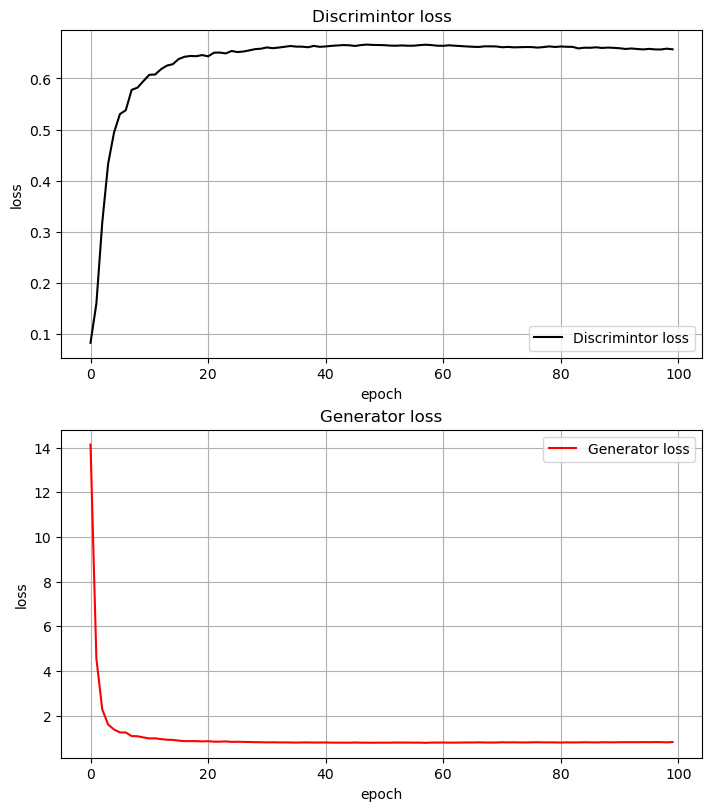

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), layout='constrained')

disc = pd.read_csv('loss_discriminator.csv')
gen = pd.read_csv('loss_generator.csv')

ax1.plot(disc['step'], disc['value'], color='black', label='Discrimintor loss')
ax2.plot(gen['step'], gen['value'], color='red', label='Generator loss')

ax1.set(
    xlabel=('epoch'),
    ylabel=('loss'),
    title=('Discrimintor loss')
)
ax2.set(
    xlabel=('epoch'),
    ylabel=('loss'),
    title=('Generator loss')
)
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)


Generated digits after 0-th iteration:


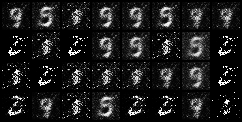

Generated digits after 10-th iteration:


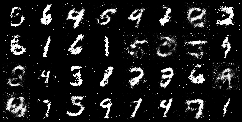

Generated digits after 20-th iteration:


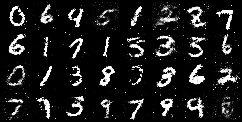

Generated digits after 30-th iteration:


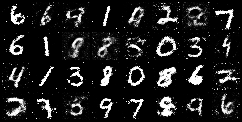

Generated digits after 40-th iteration:


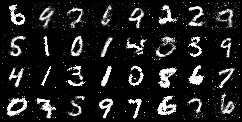

Generated digits after 50-th iteration:


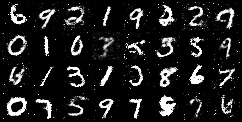

Generated digits after 60-th iteration:


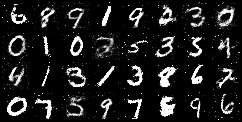

Generated digits after 70-th iteration:


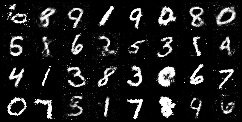

Generated digits after 80-th iteration:


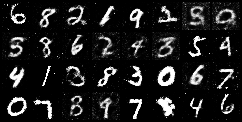

Generated digits after 90-th iteration:


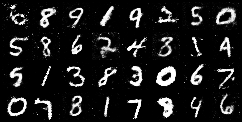

Generated digits after 99-th iteration:


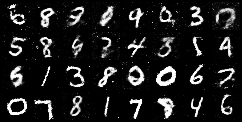

In [14]:
from IPython.display import Image, display

for i in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]:
    print(f'Generated digits after {i}-th iteration:')
    display(Image(filename=f'images/fake/fake_epoch_{i}.png'))